# ConvNeXt-Large Prediction

This notebook provides a publication-ready inference workflow for the DeathScope ConvNeXt-Large apoptosis-versus-pyroptosis classifier.

The notebook uses the packaged predictor API from `deathscope.pyro_classifier` and the training artifacts written by `ConvNeXt-Large_training.ipynb`.

Expected artifacts:
- `training/ConvNeXt/model_best.pth`
- `training/ConvNeXt/classes.json`
- optional `training/ConvNeXt/config.json`


In [2]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import cv2
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    candidate = Path.cwd().resolve()
    while candidate != candidate.parent and not (candidate / "pyproject.toml").exists():
        candidate = candidate.parent
    if not (candidate / "pyproject.toml").exists():
        raise FileNotFoundError("Could not locate the repository root containing pyproject.toml.")
    return candidate


repo_root = find_repo_root()
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from deathscope.pyro_classifier import DEFAULT_ARCHITECTURE, PyroPredictorConfig, get_predictor

print(f"Repository root: {repo_root}")


Repository root: /media/capp/TMP2/DeathScope


## Configuration

Defaults point to the training artifacts generated in this repository. Update `IMAGE_PATH` or `BATCH_INPUT_DIR` to run inference on your own cropped regions.


In [9]:
RUN_DIR = repo_root / "training/ConvNeXt"
MODEL_PATH = RUN_DIR / "model_best.pth"
CLASSES_PATH = RUN_DIR / "classes.json"
CONFIG_PATH = RUN_DIR / "config.json"

SINGLE_IMAGE_CANDIDATES = [
    repo_root / "training/ConvNeXt/source_data/LN/pyroptosis",
]
BATCH_DIR_CANDIDATES = [
    repo_root / "training/ConvNeXt/source_data/LN"
]
OUTPUT_DIR = RUN_DIR / "prediction_outputs"

DEVICE = None  # None selects cuda when available, otherwise cpu
BATCH_SIZE = 32
TOP_K_BATCH_ROWS = 10

IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}


def first_image_in_dir(directory: Path) -> Path | None:
    if not directory.exists():
        return None
    for path in sorted(directory.rglob("*")):
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES:
            return path
    return None


def first_existing_image(candidates: list[Path]) -> Path | None:
    for directory in candidates:
        image_path = first_image_in_dir(directory)
        if image_path is not None:
            return image_path
    return None


def first_existing_dir(candidates: list[Path]) -> Path | None:
    for directory in candidates:
        if directory.exists():
            return directory
    return None


IMAGE_PATH = first_existing_image(SINGLE_IMAGE_CANDIDATES)
BATCH_INPUT_DIR = first_existing_dir(BATCH_DIR_CANDIDATES)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH}")
if not CLASSES_PATH.is_file():
    raise FileNotFoundError(f"Class mapping not found: {CLASSES_PATH}")
if IMAGE_PATH is None:
    raise FileNotFoundError(
        "Could not find any example image in the configured candidate directories. "
        f"Checked: {[str(path) for path in SINGLE_IMAGE_CANDIDATES]}"
    )
if BATCH_INPUT_DIR is None:
    raise FileNotFoundError(
        "Could not find any batch input directory in the configured candidate directories. "
        f"Checked: {[str(path) for path in BATCH_DIR_CANDIDATES]}"
    )

print(f"Model:        {MODEL_PATH}")
print(f"Classes:      {CLASSES_PATH}")
print(f"Single image: {IMAGE_PATH}")
print(f"Batch root:   {BATCH_INPUT_DIR}")


Model:        /media/capp/TMP2/DeathScope/training/ConvNeXt/model_best.pth
Classes:      /media/capp/TMP2/DeathScope/training/ConvNeXt/classes.json
Single image: /media/capp/TMP2/DeathScope/training/ConvNeXt/source_data/LN/pyroptosis/VID2232_D1_1_00d00h00m_apoptosis_region_10_c3861944.png
Batch root:   /media/capp/TMP2/DeathScope/training/ConvNeXt/source_data/LN


## Load Predictor

The predictor uses the same normalization and architecture settings as the packaged DeathScope pyroptosis classifier.


In [4]:
def load_training_config(config_path: Path) -> dict:
    if not config_path.is_file():
        return {}
    with config_path.open("r", encoding="utf-8") as file:
        return json.load(file)


def infer_image_size(config_payload: dict) -> int:
    value = config_payload.get("image_size", 48)
    return int(value)


training_config = load_training_config(CONFIG_PATH)
predictor_config = PyroPredictorConfig(
    model_path=MODEL_PATH,
    classes_path=CLASSES_PATH,
    image_size=infer_image_size(training_config),
    architecture=training_config.get("architecture", DEFAULT_ARCHITECTURE),
    device=DEVICE,
)
predictor = get_predictor(
    model_path=predictor_config.model_path,
    classes_path=predictor_config.classes_path,
    image_size=predictor_config.image_size,
    architecture=predictor_config.architecture,
    device=predictor_config.device,
)

with CLASSES_PATH.open("r", encoding="utf-8") as file:
    classes_payload = json.load(file)
idx_to_class = {int(index): label for index, label in classes_payload["idx_to_class"].items()}

print(f"Architecture: {predictor_config.architecture}")
print(f"Image size:   {predictor_config.image_size}")
print(f"Device:       {predictor.device}")
print(f"Classes:      {idx_to_class}")


Architecture: convnext_large.fb_in22k_ft_in1k
Image size:   48
Device:       cuda
Classes:      {0: 'apoptosis', 1: 'pyroptosis'}


## Single-Image Prediction

This cell runs inference on one crop and visualizes the predicted label together with the class probabilities.


,class_name,probability
0,pyroptosis,0.924724
1,apoptosis,0.075276


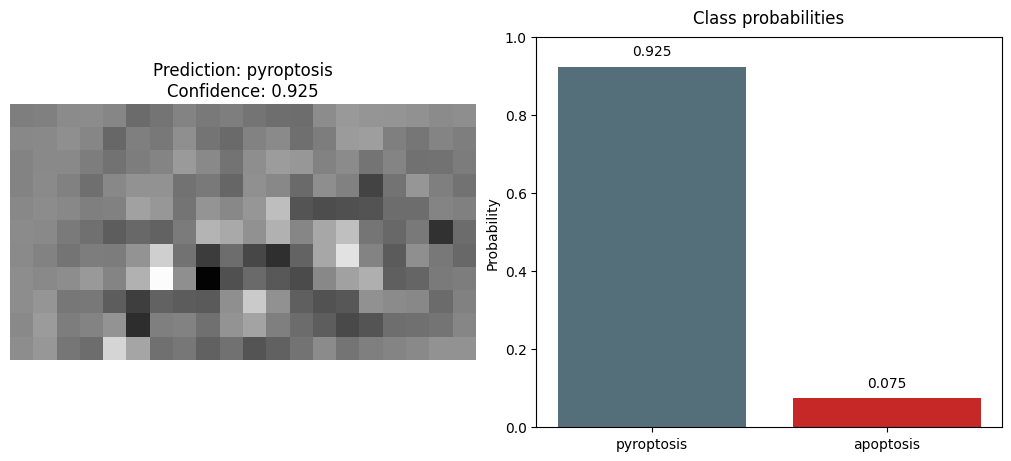

In [5]:
def read_image_rgb(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found or unreadable: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


image_rgb = read_image_rgb(IMAGE_PATH)
prediction = predictor.predict(image_rgb)
probability_df = pd.DataFrame(
    {
        "class_name": list(prediction.probabilities.keys()),
        "probability": list(prediction.probabilities.values()),
    }
).sort_values("probability", ascending=False, ignore_index=True)

display(probability_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
axes[0].imshow(image_rgb)
axes[0].set_title(f"Prediction: {prediction.label}\nConfidence: {prediction.confidence:.3f}")
axes[0].axis("off")

axes[1].bar(probability_df["class_name"], probability_df["probability"], color=["#546e7a", "#c62828"])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel("Probability")
axes[1].set_title("Class probabilities",pad=10)
for index, value in enumerate(probability_df["probability"]):
    axes[1].text(index, value + 0.02, f"{value:.3f}", ha="center", va="bottom")
plt.show()


## Export Overlay

This optional step saves a simple labeled overlay for reports or manual review.


In [6]:
base_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
text = f"{prediction.label} ({prediction.confidence * 100:.1f}%)"

height, width = base_image.shape[:2]
min_dim = max(1, min(height, width))
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = max(0.3, min(0.7, min_dim / 120.0))
thickness = max(1, int(round(min_dim / 90.0)))
inner_padding = max(4, int(round(min_dim / 18.0)))
outer_padding = max(8, int(round(min_dim / 10.0)))

text_size, baseline = cv2.getTextSize(text, font, font_scale, thickness)
text_width, text_height = text_size
header_height = text_height + baseline + inner_padding * 2
canvas_width = max(width + outer_padding * 2, text_width + outer_padding * 2 + inner_padding * 2)
canvas_height = header_height + height + outer_padding * 2

overlay_bgr = np.full((canvas_height, canvas_width, 3), 255, dtype=np.uint8)
image_x0 = (canvas_width - width) // 2
image_y0 = header_height + outer_padding
overlay_bgr[image_y0:image_y0 + height, image_x0:image_x0 + width] = base_image

header_x0 = (canvas_width - (text_width + inner_padding * 2)) // 2
header_y0 = outer_padding // 2
header_x1 = header_x0 + text_width + inner_padding * 2
header_y1 = header_y0 + header_height
text_org = (header_x0 + inner_padding, header_y1 - baseline - inner_padding)

cv2.rectangle(overlay_bgr, (header_x0, header_y0), (header_x1, header_y1), (0, 0, 0), thickness=-1)
cv2.putText(overlay_bgr, text, text_org, font, font_scale, (0, 255, 255), thickness, cv2.LINE_AA)

overlay_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_prediction_overlay.png"
cv2.imwrite(str(overlay_path), overlay_bgr)
print(f"Saved overlay to {overlay_path}")


Saved overlay to /media/capp/TMP2/DeathScope/training/ConvNeXt/prediction_outputs/VID2232_D1_1_00d00h00m_apoptosis_region_10_c3861944_prediction_overlay.png


## Batch Prediction

This section walks a directory tree of crop images, performs batched inference, and writes a CSV summary for downstream analysis.


In [10]:
IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}


def iter_image_paths(root: Path) -> list[Path]:
    return sorted([path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES])


def infer_source_label(path: Path, root: Path) -> str | None:
    parts = path.relative_to(root).parts
    for part in parts:
        lower = part.lower()
        if lower in {"apoptosis", "pyroptosis", "necroptosis"}:
            return lower
    return None


batch_paths = iter_image_paths(BATCH_INPUT_DIR)
if not batch_paths:
    raise FileNotFoundError(f"No supported images found under {BATCH_INPUT_DIR}")

batch_images = [read_image_rgb(path) for path in batch_paths]
batch_predictions = predictor.predict_many(batch_images, batch_size=BATCH_SIZE)

records = []
for path, pred in zip(batch_paths, batch_predictions):
    row = {
        "image_path": str(path.relative_to(repo_root)),
        "source_label": infer_source_label(path, BATCH_INPUT_DIR),
        "predicted_label": pred.label,
        "confidence": pred.confidence,
    }
    for class_name, probability in pred.probabilities.items():
        row[f"prob_{class_name}"] = probability
    records.append(row)

batch_df = pd.DataFrame(records)
batch_csv_path = OUTPUT_DIR / "batch_predictions.csv"
batch_df.to_csv(batch_csv_path, index=False)

summary_df = (
    batch_df.groupby("predicted_label")
    .size()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False, ignore_index=True)
)

display(summary_df)
display(batch_df.head(TOP_K_BATCH_ROWS))
print(f"Saved batch predictions to {batch_csv_path}")


,predicted_label,count
0,pyroptosis,2947
1,apoptosis,49


,image_path,source_label,predicted_label,confidence,prob_apoptosis,prob_pyroptosis
0,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.924725,0.075275,0.924725
1,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.977481,0.022519,0.977481
2,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.974399,0.025601,0.974399
3,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.927870,0.072130,0.927870
4,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.976968,0.023032,0.976968
5,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,apoptosis,0.973963,0.973963,0.026037
6,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.976085,0.023915,0.976085
7,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.976598,0.023402,0.976598
8,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.976099,0.023901,0.976099
9,training/ConvNeXt/source_data/LN/pyroptosis/VI...,pyroptosis,pyroptosis,0.974534,0.025466,0.974534


Saved batch predictions to /media/capp/TMP2/DeathScope/training/ConvNeXt/prediction_outputs/batch_predictions.csv


## If Ground-Truth Labels Are Encoded In Folder Names

For a labeled directory tree, this cell computes a simple agreement table using the class-like folder names found under `BATCH_INPUT_DIR`.


In [11]:
evaluable_df = batch_df.dropna(subset=["source_label"]).copy()
if evaluable_df.empty:
    print("No class-like folder names were found under the batch input directory; skipping agreement summary.")
else:
    agreement_df = (
        evaluable_df.groupby(["source_label", "predicted_label"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["source_label", "count"], ascending=[True, False], ignore_index=True)
    )
    evaluable_df["correct_label_match"] = evaluable_df["source_label"] == evaluable_df["predicted_label"]
    accuracy_proxy = float(evaluable_df["correct_label_match"].mean())
    display(agreement_df)
    print(f"Folder-label agreement: {accuracy_proxy:.3f}")


,source_label,predicted_label,count
0,pyroptosis,pyroptosis,2947
1,pyroptosis,apoptosis,49


Folder-label agreement: 0.984
